In [4]:
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

The history saving thread hit an unexpected error (OperationalError('disk I/O error')).History will not be written to the database.


In [5]:
from libs.engine import Value
from libs.nn import Neuron, Layer, MLP

np.random.seed(1337)
random.seed(1337)

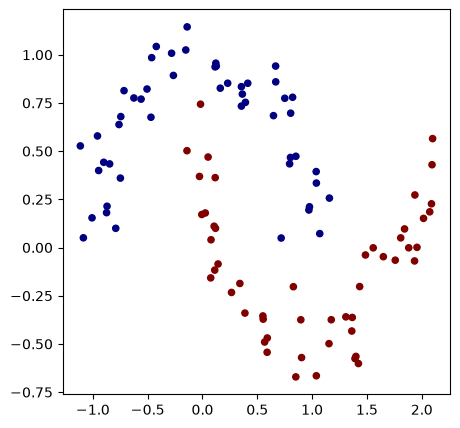

In [14]:
# make up a dataset

from sklearn.datasets import make_moons, make_blobs
X, y = make_moons(n_samples=100, noise=0.1)

y = y*2 - 1 # make y be -1 or 1
# visualize in 2D
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, s=20, cmap='jet')



In [15]:
X

array([[ 1.88101391e+00, -1.16515726e-03],
       [-1.39782923e-01,  1.14462300e+00],
       [-8.70275040e-01,  2.14313054e-01],
       [ 7.52531198e-02, -1.57299703e-01],
       [ 1.75816900e+00, -6.54567021e-02],
       [ 5.89619488e-01, -5.43142576e-01],
       [ 1.17455360e+00, -3.74402988e-01],
       [ 1.55717533e+00, -1.45351957e-03],
       [ 5.51016769e-01, -3.54698720e-01],
       [ 1.30772759e+00, -3.59485643e-01],
       [ 1.84297393e+00,  9.66278034e-02],
       [-8.46668744e-01,  4.33883215e-01],
       [ 1.03844059e+00, -6.65056154e-01],
       [ 2.07264872e+00,  1.85315341e-01],
       [ 4.13003491e-01,  8.52330258e-01],
       [ 3.91762314e-01,  7.53245264e-01],
       [ 2.09362901e+00,  4.29553711e-01],
       [-7.61221370e-01,  6.38084211e-01],
       [ 1.14909996e-01,  9.37173960e-01],
       [ 8.04285249e-01,  6.96928887e-01],
       [ 8.51323720e-01, -6.70863165e-01],
       [ 5.53843397e-01, -3.71388059e-01],
       [ 1.16060562e-01,  3.62644567e-01],
       [ 6.

In [9]:
# initialize a model 
model = MLP(2, [16, 16, 1]) # 2-layer neural network
print(model)
print("number of parameters", len(model.parameters()))

MLP of [Layer of [ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2)], Layer of [ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16)], Layer of [LinearNeuron(16)]]
number of parameters 337


In [11]:
# loss function
def loss(batch_size=None):
    
    # inline DataLoader :)
    if batch_size is None:
        Xb, yb = X, y
    else:
        ri = np.random.permutation(X.shape[0])[:batch_size]
        Xb, yb = X[ri], y[ri]
    inputs = [list(map(Value, xrow)) for xrow in Xb]
    
    # forward the model to get scores
    scores = list(map(model, inputs))
    
    # svm "max-margin" loss
    losses = [(1 + -yi*scorei).relu() for yi, scorei in zip(yb, scores)]
    data_loss = sum(losses) * (1.0 / len(losses))
    # L2 regularization
    alpha = 1e-4
    reg_loss = alpha * sum((p*p for p in model.parameters()))
    total_loss = data_loss + reg_loss
    
    # also get accuracy
    accuracy = [(yi > 0) == (scorei.data > 0) for yi, scorei in zip(yb, scores)]
    return total_loss, sum(accuracy) / len(accuracy)

total_loss, acc = loss()
print(total_loss, acc)

Value(data=2.3845687796500568) 0.19


In [12]:
# optimization
for k in range(100):
    
    # forward
    total_loss, acc = loss()
    
    # backward
    model.zero_grad()
    total_loss.backward()
    
    # update (sgd)
    learning_rate = 1.0 - 0.9*k/100
    for p in model.parameters():
        p.data -= learning_rate * p.grad
    
    if k % 1 == 0:
        print(f"step {k} loss {total_loss.data}, accuracy {acc*100}%")



step 0 loss 2.3845687796500568, accuracy 19.0%
step 1 loss 0.8811255135190095, accuracy 76.0%
step 2 loss 0.3950680257228937, accuracy 83.0%
step 3 loss 0.3174492639779163, accuracy 86.0%
step 4 loss 0.36339436896490646, accuracy 86.0%
step 5 loss 0.358353243801174, accuracy 84.0%
step 6 loss 0.4541608335400529, accuracy 87.0%
step 7 loss 0.36578757731468353, accuracy 87.0%
step 8 loss 0.3143340666087364, accuracy 89.0%
step 9 loss 0.1793049871661083, accuracy 93.0%
step 10 loss 0.15484127769470588, accuracy 96.0%
step 11 loss 0.14198397096044788, accuracy 94.0%
step 12 loss 0.13408421160217926, accuracy 95.0%
step 13 loss 0.11948352044562063, accuracy 96.0%
step 14 loss 0.1099665704202751, accuracy 96.0%
step 15 loss 0.09805437385779697, accuracy 98.0%
step 16 loss 0.09786889670618201, accuracy 97.0%
step 17 loss 0.11879004449350253, accuracy 94.0%
step 18 loss 0.07713829244967932, accuracy 98.0%
step 19 loss 0.10464055809437925, accuracy 96.0%
step 20 loss 0.13459118623318297, accura

(-1.7222875713140986, 2.027712428685901)

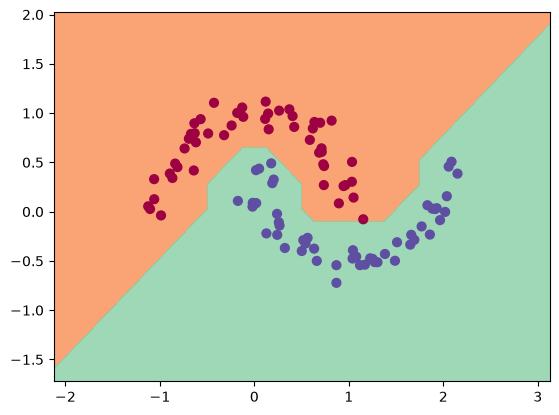

In [13]:
# visualize decision boundary

h = 0.25
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Xmesh = np.c_[xx.ravel(), yy.ravel()]
inputs = [list(map(Value, xrow)) for xrow in Xmesh]
scores = list(map(model, inputs))
Z = np.array([s.data > 0 for s in scores])
Z = Z.reshape(xx.shape)

fig = plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())

